In [27]:
from pathlib import Path
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots
import ICIW_Plots.colors
import numpy as np
import torch


plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 7,
    }
)

In [28]:
# run_id = "jkwy4zpw" # with the shorter kernel times
run_ids = [
    "8n8o3ign",
    "8ko4ckqt",
    "vz0y7ii1",
    "6bwxw3od",
]
names = [
    "Ar BU",
    "He BU",
    "Ar BT",
    "He BT",
]
model_dict = {}
for name, run_id in zip(names, run_ids):
    _, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
    model = RTDModule.load_from_checkpoint(ckpt_path)
    # model.net.conv_layers[0].set_to_direct_response()
    model_dict[name] = {
        "model": model,
        "E1": model.net.E[0].numpy(),
        "E2": model.net.E[1].numpy(),
        "E3": model.net.E[2].numpy(),
        "E4": model.net.E[3].numpy(),
        "t1": model.net.conv_layers[0].t_kernel.detach().numpy(),
        "t2": model.net.conv_layers[1].t_kernel.detach().numpy(),
        "t3": model.net.conv_layers[2].t_kernel.detach().numpy(),
        "t4": model.net.conv_layers[3].t_kernel.detach().numpy(),
        "delta_t": model.net.delta_t[0].item(),
    }

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


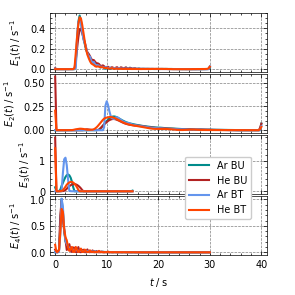

In [29]:
from cycler import cycler

fig = ICIW_Plots.figure(height=7.5 * ICIW_Plots.cm2inch)
ccycler = cycler(
    color=[
        "darkcyan",
        "firebrick",
        "cornflowerblue",
        "orangered",
    ]
)

with plt.rc_context(rc={"axes.prop_cycle": ccycler}):
    axs = ICIW_Plots.make_rect_subplots(
        fig,
        ax_width=5.5 * ICIW_Plots.cm2inch,
        ax_height=1.5 * ICIW_Plots.cm2inch,
        ax_layout=(4, 1),
        left_h=0.5,
        bottom_v=0.4,
        v_sep=0.02,
        xlabel=r"$t \;/\; \mathrm{s}$",
        ylabel=[
            r"$E_1(t)\;/\;\mathrm{s}^{-1}$",
            r"$E_2(t)\;/\;\mathrm{s}^{-1}$",
            r"$E_3(t)\;/\;\mathrm{s}^{-1}$",
            r"$E_4(t)\;/\;\mathrm{s}^{-1}$",
        ],
        xlim=(-1, 41),
        # ylim=(-0.05, 0.65),
    )
for name, E_dict in model_dict.items():
    axs[0, 0].plot(E_dict["t1"], E_dict["E1"], label=name)
    axs[1, 0].plot(E_dict["t2"], E_dict["E2"], label=name)
    axs[2, 0].plot(E_dict["t3"], E_dict["E3"], label=name)
    axs[3, 0].plot(E_dict["t4"], E_dict["E4"], label=name)
# axs[0, 0].set(
#     zorder=5,
# )
axs[3, 0].legend(bbox_to_anchor=(0.95, 1.75), loc="upper right")
fig.savefig("Es_comp_Components.png", dpi=600)

In [30]:
t_out = (0.0, 120.0)
t_in = (0.0, 5.0)
t_halfperiod = t_out[1] - t_out[0]
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
n_in = int(4 * (t_in[1] - t_in[0]) + 1)
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
automated_switching_times = np.full((20,), t_halfperiod)
switching_times_total_system = np.insert(automated_switching_times, 0, 7.5 - 1.0)
switching_times_total_system = np.cumsum(switching_times_total_system)

data_total_system = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-10032025_30ml-min_1atm_TotalSystem.npz"
    ),
    switching_times=switching_times_total_system,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)

In [31]:
data_total_system.setup("eval")

True

In [32]:
data_total_system.y.shape

torch.Size([40, 1, 481])

In [33]:
res_dict = {
    name: model["model"](
        data_total_system.x.to(torch.float), data_total_system.t_in.to(torch.float)
    )
    for name, model in model_dict.items()
}

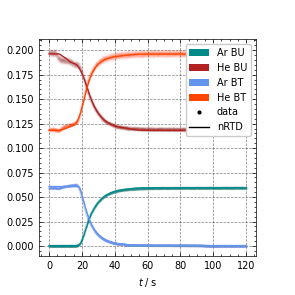

In [34]:
fig = ICIW_Plots.figure(layout="single_column")
ax = ICIW_Plots.make_rect_ax(
    fig,
    ax_height=5.5 * ICIW_Plots.cm2inch,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$x \;/\; 1$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    data_total_system.y[::4, ...],
    alpha=0.01,
    s=2,
    color="darkcyan",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    data_total_system.y[1::4, ...],
    alpha=0.01,
    s=2,
    color="firebrick",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    data_total_system.y[2::4, ...],
    alpha=0.01,
    s=2,
    color="cornflowerblue",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    data_total_system.y[3::4, ...],
    alpha=0.01,
    s=2,
    color="orangered",
)

ax.plot(
    res_dict["Ar BU"][1][0, ...].detach().numpy(),
    res_dict["Ar BU"][0][0, 0, :].detach().numpy(),
    lw=1,
    color="darkcyan",
)
ax.plot(
    res_dict["He BU"][1][1, ...].detach().numpy(),
    res_dict["He BU"][0][1, 0, :].detach().numpy(),
    lw=1,
    color="firebrick",
)
ax.plot(
    res_dict["Ar BT"][1][2, ...].detach().numpy(),
    res_dict["Ar BT"][0][2, 0, :].detach().numpy(),
    lw=1,
    color="cornflowerblue",
)
ax.plot(
    res_dict["He BT"][1][3, ...].detach().numpy(),
    res_dict["He BT"][0][3, 0, :].detach().numpy(),
    lw=1,
    color="orangered",
)

legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    "Ar BU",
    "He BU",
    "Ar BT",
    "He BT",
    "data",
    "nRTD",
]

ax.legend(legend_handles, legend_names, loc="upper right")
plt.savefig("response_TotalSystem_comp_Components.png", dpi=600)

In [35]:
normalized_signals = (data_total_system.y - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
normalized_res_dict = {
    name: (res[0] - data_total_system.x[:, :, [0]])
    / (data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]])
    for name, res in res_dict.items()
}
print(data_total_system.y.shape)
print(normalized_signals.shape)

torch.Size([40, 1, 481])
torch.Size([40, 1, 481])


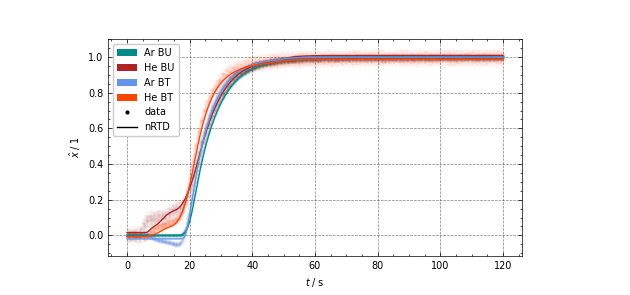

In [36]:
fig = ICIW_Plots.figure(layout="double_column")
ax = ICIW_Plots.make_rect_ax(
    fig,
    ax_height=5.5 * ICIW_Plots.cm2inch,
    ax_width=10.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$\hat{x} \;/\; 1$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    normalized_signals[::4, ...],
    alpha=0.02,
    s=2,
    color="darkcyan",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    normalized_signals[1::4, ...],
    alpha=0.02,
    s=2,
    color="firebrick",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    normalized_signals[2::4, ...],
    alpha=0.02,
    s=2,
    color="cornflowerblue",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    normalized_signals[3::4, ...],
    alpha=0.02,
    s=2,
    color="orangered",
)

ax.plot(
    res_dict["Ar BU"][1][0, ...].detach().numpy(),
    normalized_res_dict["Ar BU"][0, 0, :].detach().numpy(),
    lw=1,
    color="darkcyan",
)
ax.plot(
    res_dict["He BU"][1][1, ...].detach().numpy(),
    normalized_res_dict["He BU"][1, 0, :].detach().numpy(),
    lw=1,
    color="firebrick",
)
ax.plot(
    res_dict["Ar BT"][1][2, ...].detach().numpy(),
    normalized_res_dict["Ar BT"][2, 0, :].detach().numpy(),
    lw=1,
    color="cornflowerblue",
)
ax.plot(
    res_dict["He BT"][1][3, ...].detach().numpy(),
    normalized_res_dict["He BT"][3, 0, :].detach().numpy(),
    lw=1,
    color="orangered",
)
legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    "Ar BU",
    "He BU",
    "Ar BT",
    "He BT",
    "data",
    "nRTD",
]

ax.legend(legend_handles, legend_names)